# CSCI 4052U — Lab 1
## Shallow Networks, Losses, and Generalization

**Units.** `preliminaries_to_machine_learning`, `training_models`
**Duration.** 1 hour

By the end of this lab you will have, with your own code and your own numbers:

| Exercise | Learning outcome |
|---|---|
| 1 | **`construct-shallow-network`** — construct a shallow ReLU network and trace how it produces a piecewise linear function |
| 2 | **`derive-loss-from-likelihood`** — derive a loss by having the network predict the parameters of a distribution over outputs |
| 3 | **`decompose-test-error`** — separate train from test error and say which of noise, bias, and variance dominates |

### How this notebook works

- Cells marked **SETUP** are provided. Run them; do not change them.
- Cells marked **YOUR CODE** are yours. Each contains `raise NotImplementedError()` — delete that line and write your answer.
- Cells marked **CHECK** verify your work and print `[ok]` when you are right. If a check fails, read its message: it tells you what is wrong, not just that something is.

Support code lives in `lab1_utils.py`. You never need to edit that file.


---
## Setup


In [1]:
# COLAB SETUP -- run this cell first.  Outside Colab it does nothing.
import importlib.util
import subprocess
import sys
import urllib.request

try:  # find_spec raises when the parent package is absent, so import instead
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Colab already ships torch and torchvision; install only what is missing.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "lightning", "torchmetrics"], check=True)

# Fetch the lab's support module when it is not already beside the notebook.
if importlib.util.find_spec("lab1_utils") is None:
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kenpu-uoit/csci4052u-machine-learning-2/main/labs/lab1/lab1_utils.py", "lab1_utils.py")
    print("downloaded lab1_utils.py")


downloaded lab1_utils.py


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


downloading MNIST-1D to /content/data/mnist1d_data.pkl ...
sine:    60 train, 200 test
MNIST-1D: 4000 train, 1000 test, 40 inputs, 10 classes


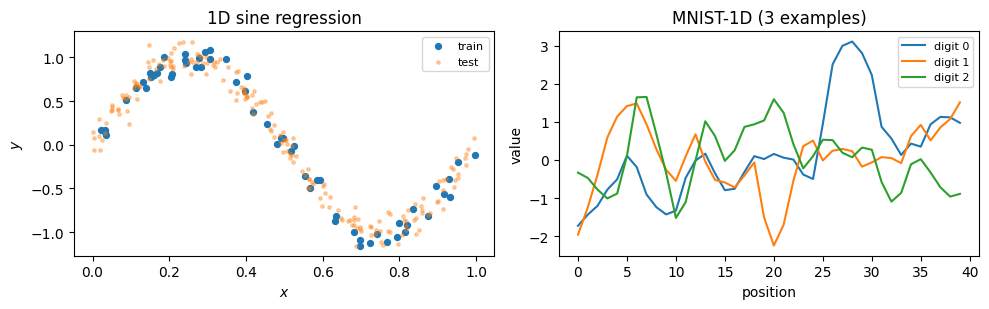

In [2]:
# SETUP -- run this cell first
# Every library is imported under a name, and its symbols are reached through
# that name: utils.SineDataModule, nn.Linear, F.mse_loss, and so on.
import math

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import lab1_utils as utils

utils.quiet_lightning()
L.seed_everything(0, workers=True)

# The two datasets used in this lab.
sine = utils.SineDataModule(n_train=60, n_test=200, batch_size=16, noise=0.1)
mnist1d = utils.MNIST1DDataModule(batch_size=100)   # downloads once, then cached in ./data

print(f"sine:    {len(sine.x_train)} train, {len(sine.x_test)} test")
print(f"MNIST-1D: {len(mnist1d.x_train)} train, {len(mnist1d.x_test)} test, "
      f"{mnist1d.x_train.shape[1]} inputs, 10 classes")
utils.plot_datasets(sine, mnist1d)


---
# Exercise 1 — A shallow ReLU network, by hand
**Outcome A · about 15 minutes**

The `preliminaries_to_machine_learning` notes define a shallow network with $D$ hidden units as

$$h_d = a[\theta_{d0} + \theta_{d1}x], \qquad y = \phi_0 + \sum_{d=1}^{D}\phi_d h_d,$$

where $a[z] = \mathrm{ReLU}[z] = \max(0, z)$.

Each hidden unit clips a line, and the point at which unit $d$ switches between clipped and
unclipped — its **joint** — is where its line crosses zero:

$$\theta_{d0} + \theta_{d1}x = 0 \quad\Longrightarrow\quad x = -\frac{\theta_{d0}}{\theta_{d1}}.$$

You will work with the exact network from the notes: $D = 3$, with

$$\phi = \{-0.23,\ -1.3,\ 1.3,\ 0.66\}, \qquad
\theta = \{(-0.2, 0.4),\ (-0.9, 0.9),\ (1.1, -0.7)\}.$$

These are already loaded as `utils.EXAMPLE_PHI` (shape `(4,)`, the offset first) and `utils.EXAMPLE_THETA`
(shape `(3, 2)`, each row an intercept and a slope).


### 1a — Implement the network · *coding*

Write `shallow_forward` using **plain tensor arithmetic only**: no `nn.Module`, no `autograd`,
no loops over the data. Broadcasting does the work.

Given `x` of shape `(N,)`, return the network output of shape `(N,)`.

*Hint.* `theta[:, 0] + theta[:, 1] * x.unsqueeze(1)` gives you all `(N, D)` pre-activations at once.


In [21]:
def shallow_forward(x, theta, phi):
    """Evaluate a shallow ReLU network.

    x     : (N,)     input values
    theta : (D, 2)   row d is (intercept, slope) of hidden unit d
    phi   : (D + 1,) output offset phi_0 followed by the weights phi_1 ... phi_D

    returns: (N,) the network output y
    """
    pre = theta[:, 0] + theta[:, 1] * x.unsqueeze(1)

    # ReLU clips each unit's line at zero
    h = torch.clamp(pre, min=0)          # (N, D)

    # weighted sum over hidden units plus the offset: (N, D) @ (D,) -> (N,)
    return phi[0] + h @ phi[1:]

In [22]:
# CHECK 1a
utils.check_shallow_forward(shallow_forward)


[ok] 1a: shallow_forward matches the reference network to 1e-6.


### 1b — See the joints · *coding and visualization*

Three things to produce:

1. **A plot.** A 2x2 panel over $x \in [0, 2]$: the three hidden activations $h_1, h_2, h_3$ in
   the first three panels, and the network output $y$ in the fourth. On every panel, draw a
   dotted vertical line at each joint.
2. **`joints`** — a tensor of the three joint locations, computed from $\theta$ with the formula above.
3. **`slope`** — the slope of the output on the region $x \in (0.5, 1.0)$, **measured from your
   plotted curve** (a rise-over-run between two points inside the region), not from the formula.

The notes state that on this region $h_1$ and $h_3$ are active while $h_2$ is clipped, so the
slope should come out to $\theta_{11}\phi_1 + \theta_{31}\phi_3$. Your measurement is the check
on that claim.


joints: [0.5, 1.0, 1.571428656578064]
measured slope on (0.5, 1.0): -0.9820
formula theta_11*phi_1 + theta_31*phi_3: -0.9820


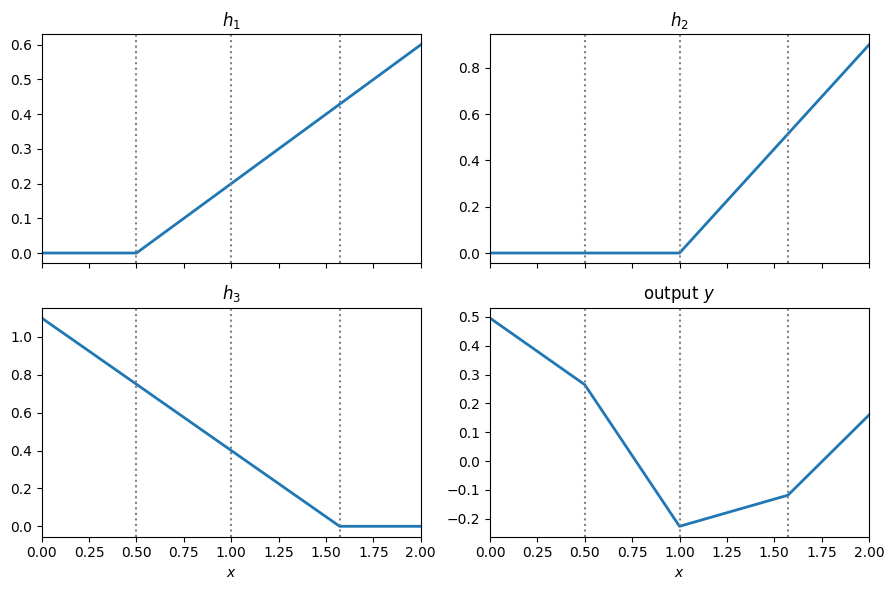

In [23]:
x = torch.linspace(0, 2, 2001)

theta = utils.EXAMPLE_THETA
phi = utils.EXAMPLE_PHI

# 1. compute the joints from utils.EXAMPLE_THETA
joints = -theta[:, 0] / theta[:, 1]

# 2. measure the slope on the region 0.5 < x < 1.0 from the network output
y = shallow_forward(x, theta, phi)
i1 = torch.argmin((x - 0.6).abs())
i2 = torch.argmin((x - 0.9).abs())
slope = (y[i2] - y[i1]) / (x[i2] - x[i1])

print("joints:", joints.tolist())
print(f"measured slope on (0.5, 1.0): {slope.item():.4f}")
print(f"formula theta_11*phi_1 + theta_31*phi_3: {(theta[0,1]*phi[1] + theta[2,1]*phi[3]).item():.4f}")

# 3. draw the 2x2 panel of h_1, h_2, h_3 and y, with the joints marked
h = torch.clamp(theta[:, 0] + theta[:, 1] * x.unsqueeze(1), min=0)   # (N, 3)

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
curves = [h[:, 0], h[:, 1], h[:, 2], y]
titles = ["$h_1$", "$h_2$", "$h_3$", "output $y$"]

for ax, curve, title in zip(axes.flat, curves, titles):
    ax.plot(x, curve, lw=2)
    for j in joints:
        ax.axvline(j.item(), color="0.5", ls=":")
    ax.set_title(title)
    ax.set_xlim(0, 2)

axes[1, 0].set_xlabel("$x$")
axes[1, 1].set_xlabel("$x$")
fig.tight_layout()
plt.show()

In [24]:
# CHECK 1b
utils.check_joints_and_slope(joints, slope)


[ok] 1b: joints at {0.5, 1.0, 1.571} and the shaded-region slope is -0.982.


---
# Exercise 2 — The loss recipe
**Outcome B · about 25 minutes**

The `training_models` notes give a four-step recipe that produces *every* loss in this course:

1. Choose a probability distribution $Pr(y|\theta)$ over the output domain, with parameters $\theta$.
2. Set the network to predict those parameters: $\theta = f[x, \phi]$.
3. Find the $\hat\phi$ minimising the **negative log-likelihood** over the training pairs.
4. At test time return the distribution, or the value that maximises it.

You will run the recipe twice. The first time the distribution is a **normal** and you will get
least squares. The second time you change **only step 1** to a **categorical** distribution and
you get cross-entropy. Nothing else about the procedure changes — that is the point of the exercise.


### 2a — Least squares *is* the Gaussian negative log-likelihood · *coding*

Step 1 picks the univariate normal, step 2 sets $\mu = f[x,\phi]$, and step 3 writes

$$L[\phi] = -\sum_{i=1}^{I}\log\left[\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_i - f[x_i,\phi])^2}{2\sigma^2}\right]\right].$$

Implement this **directly from the definition** — take the log of the density and sum it, without
simplifying on paper first. The check will then show you what the algebra in the notes shows: what
you wrote equals $\tfrac{1}{2\sigma^2}\sum_i (y_i - f[x_i,\phi])^2$ plus a constant, so minimising
it and minimising the sum of squares are the same thing.


In [25]:
def gaussian_nll(pred, y, sigma):
    """Negative log-likelihood of y under N(pred, sigma^2), summed over examples.

    pred  : (I, 1) the network output, used as the mean mu
    y     : (I, 1) the observed targets
    sigma : float, the fixed standard deviation

    returns: a scalar tensor
    """
    density = (1 / math.sqrt(2 * math.pi * sigma**2)) * torch.exp(-(y - pred)**2 / (2 * sigma**2))
    return -torch.log(density).sum()


In [26]:
# CHECK 2a
utils.check_gaussian_nll(gaussian_nll)


[ok] 2a: your NLL equals 0.5*SSE/sigma^2 + const, and ranks fits like least squares.


### 2b — Fit the regression model · *coding and visualization*

Now minimise that loss by gradient descent. `utils.LitRegressor` in `lab1_utils.py` supplies
`forward`, `validation_step` and `test_step`; you supply the three pieces that define the model
and its optimisation. Complete them by **subclassing in this notebook** — do not edit `lab1_utils.py`.

- `__init__` — build `self.net` as `nn.Sequential`: `width` is the hidden size, so the shape is
  1 → `width` (ReLU) → `width` (ReLU) → 1.
- `training_step` — compute the mean squared error between `self(x)` and `y`, log it under the
  name `"train_loss"` with `on_epoch=True`, and return it.
- `configure_optimizers` — return `torch.optim.Adam` over `self.parameters()` at `self.hparams.lr`.

Then fit for 200 epochs and plot both the loss curve and the fitted function.


In [27]:
class MyRegressor(utils.LitRegressor):
    def __init__(self, width=20, lr=0.01):
        super().__init__(width=width, lr=lr)
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 1),
        )

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = F.mse_loss(self(x), y)
        self.log("train_loss", loss, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


# fit the model  (the utils.LossHistory callback records the per-epoch loss for you)
history = utils.LossHistory()
model = MyRegressor(width=20, lr=0.01)
trainer = utils.make_trainer(max_epochs=200, quiet=True)
trainer.callbacks.append(history)
trainer.fit(model, datamodule=sine)

# YOUR CODE HERE -- plot history.losses against the epoch number (log-y reads well),
# then call utils.plot_fit(model, sine) to overlay the fitted function on the data


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [28]:
# CHECK 2b
utils.check_regressor(model, sine, trainer, history.losses)


[ok] 2b: training MSE 0.0079 < 0.05, and the loss fell from 0.300 to 0.009.


**Look at your fit before moving on.** It is piecewise linear, exactly like Exercise 1 — but with
20 hidden units per layer instead of 3, the joints are dense enough that the curve looks smooth.
The mechanism has not changed; only the number of pieces has.


### 2c — Change step 1, and only step 1 · *coding*

Now the outputs are class labels $y \in \{0, \dots, 9\}$ rather than real numbers, so step 1 of
the recipe picks the **categorical** distribution instead of the normal. Its $K$ parameters come
from the softmax of $K$ network outputs, and the negative log-likelihood is the **multiclass
cross-entropy** loss.

Everything else is already written for you in `utils.LitClassifier`: the 40 → 100 → 100 → 10 network,
the optimizer, the accuracy metric, `validation_step`, and `test_step`. The **only** thing that
differs from Exercise 2b is the loss function — which is exactly the claim the notes make.

Write `training_step` using `F.cross_entropy`.


In [29]:
class MyClassifier(utils.LitClassifier):
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss, on_epoch=True)
        return loss


classifier = MyClassifier(width=100, lr=0.1)
clf_trainer = utils.make_trainer(max_epochs=30, quiet=True)
clf_trainer.fit(classifier, datamodule=mnist1d)
results = clf_trainer.test(classifier, datamodule=mnist1d, verbose=False)
print(results)


[{'test_loss': 1.7665175199508667, 'test_acc': 0.6513928174972534}]


In [30]:
# CHECK 2c
utils.check_classifier(results)


[ok] 2c: MNIST-1D test accuracy 0.651 > 0.55 (the notes report about 0.60).


---
# Exercise 3 — Capacity, train error, and test error
**Outcome C · about 15 minutes**

The `training_models` notes decompose the expected test error of a least-squares model into three
additive parts:

$$\mathbb{E}\big[\text{test error}\big] =
\underbrace{\mathbb{E}_\mathcal{D}\Big[\big(f[x,\phi[\mathcal{D}]] - f_\mu[x]\big)^2\Big]}_{\text{variance}} +
\underbrace{\big(f_\mu[x] - \mu[x]\big)^2}_{\text{bias}} +
\underbrace{\sigma^2}_{\text{noise}}.$$

- **Noise** is irreducible. Our data is generated with $\varepsilon \sim \mathcal{N}(0, 0.25^2)$,
  so **no model can achieve a test MSE below $\sigma^2 = 0.0625$**. You will see this floor in your plot.
- **Bias** is the model being too inflexible to represent the true function. It shows up as
  *high training error*.
- **Variance** is the fit changing with the particular training sample. It shows up as a *gap
  between training and test error*.

To make all three visible you need a small, noisy training set — 15 points with
$\sigma = 0.25$, following the notes, which use fifteen points for exactly this demonstration.


In [33]:
# SETUP -- a deliberately small and noisy training set
sine_small = utils.SineDataModule(n_train=15, n_test=200, batch_size=8, noise=0.25)
print(f"{len(sine_small.x_train)} training points, noise floor sigma^2 = {sine_small.noise**2:.4f}")


15 training points, noise floor sigma^2 = 0.0625


### 3a — Fit at a given capacity · *coding*

Write `fit_and_score(width)`, which trains a fresh `MyRegressor` of the given hidden width on
`sine_small` and returns the tuple `(train_mse, test_mse)`.

Three things to get right:

- Call `L.seed_everything(0, workers=True)` first, so that every width starts from a comparable
  initialization and the sweep is a fair comparison.
- Use `utils.make_trainer(max_epochs=300, quiet=True)` — `quiet=True` suppresses the progress bar, which
  matters once you are fitting seven models.
- Score under `torch.no_grad()`, using `F.mse_loss` against `sine_small.x_train` / `.y_train` and
  `sine_small.x_test` / `.y_test`.


In [34]:
def fit_and_score(width):
    """Train a MyRegressor of the given hidden width on sine_small.

    returns: (train_mse, test_mse) as plain floats
    """
    L.seed_everything(0, workers=True)

    model = MyRegressor(width=width, lr=0.01)
    trainer = utils.make_trainer(max_epochs=300, quiet=True)
    trainer.fit(model, datamodule=sine_small)

    with torch.no_grad():
        train_mse = F.mse_loss(model(sine_small.x_train), sine_small.y_train).item()
        test_mse = F.mse_loss(model(sine_small.x_test), sine_small.y_test).item()

    return train_mse, test_mse

In [35]:
# CHECK 3a
utils.check_fit_and_score(fit_and_score)


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


[ok] 3a: width 16 gives train MSE 0.0535 and test MSE 0.1455.


### 3b — Sweep the capacity · *coding and visualization*

Sweep `widths = [1, 2, 4, 8, 16, 64, 256]`, collecting `train_errors` and `test_errors`, then plot
them with

```python
utils.plot_capacity_sweep(widths, train_errors, test_errors, noise_floor=sine_small.noise**2)
```

The whole sweep takes under ten seconds.


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


width   1: train MSE 0.6510   test MSE 0.6678


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


width   2: train MSE 0.6510   test MSE 0.6666


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


...

width   8: train MSE 0.0727   test MSE 0.1776


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


width  16: train MSE 0.0535   test MSE 0.1455


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


width  64: train MSE 0.0283   test MSE 0.1117
width 256: train MSE 0.0257   test MSE 0.1188


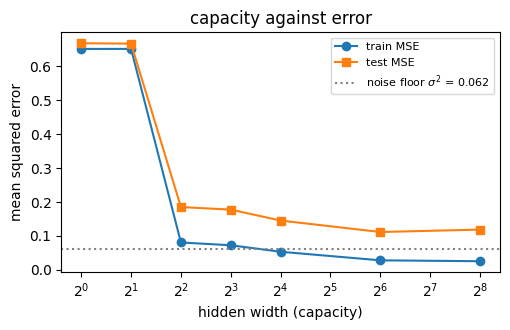

In [36]:
widths = [1, 2, 4, 8, 16, 64, 256]

train_errors = []
test_errors = []
for w in widths:
    train_mse, test_mse = fit_and_score(w)
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    print(f"width {w:>3}: train MSE {train_mse:.4f}   test MSE {test_mse:.4f}")

utils.plot_capacity_sweep(widths, train_errors, test_errors, noise_floor=sine_small.noise**2)


In [37]:
# CHECK 3b
utils.check_sweep(widths, train_errors, test_errors, noise_floor=sine_small.noise**2)


[ok] 3b: underfitting confirmed at width 1.
      test error is lowest at width 64.
      the gap at width 256 is 0.0932.
      the noise floor is sigma^2 = 0.0625; the best test error is 0.1117.
      use these three numbers in your table.


### 3c — Read the decomposition off your numbers · *coding*

The three terms of the decomposition are all present in the sweep you just ran. Compute each
one from `widths`, `train_errors` and `test_errors`:

- **`underfit_error`** — the *training* error at the smallest width. A model too inflexible to
  fit even the training data is showing **bias**.
- **`gap`** — test error minus training error at the largest width. A model that fits the sample
  far better than the function is showing **variance**.
- **`best_width`** — the width at which *test* error is smallest.
- **`noise_floor`** — $\sigma^2$ for this dataset, which no model can cross however much
  capacity you give it.


In [38]:
i_small = int(np.argmin(widths))
i_large = int(np.argmax(widths))

underfit_error = train_errors[i_small]
gap = test_errors[i_large] - train_errors[i_large]
best_width = widths[int(np.argmin(test_errors))]
noise_floor = sine_small.noise**2

print(f"underfit_error (bias):     {underfit_error:.4f}  at width {widths[i_small]}")
print(f"gap (variance):            {gap:.4f}  at width {widths[i_large]}")
print(f"best_width:                {best_width}  (test MSE {min(test_errors):.4f})")
print(f"noise_floor (sigma^2):     {noise_floor:.4f}")

underfit_error (bias):     0.6510  at width 1
gap (variance):            0.0932  at width 256
best_width:                64  (test MSE 0.1117)
noise_floor (sigma^2):     0.0625


In [39]:
# CHECK 3c
utils.check_decomposition(widths, train_errors, test_errors, noise_floor,
                          underfit_error, gap, best_width)


[ok] 3c: bias, variance and noise read off correctly.
      bias   -> train error 0.6510 at width 1: too inflexible to fit the data at all.
      variance -> train/test gap 0.0932 at width 256: the extra capacity fits the sample, not the function.
      noise  -> test error bottoms at 0.1117, above the floor sigma^2 = 0.0625, which no model can cross.
      test error is lowest at width 64.


---
## Done

You have covered three of the twenty-four learning outcomes in these two units:

- **`construct-shallow-network`** — you built a ReLU network from arithmetic, located its joints
  at $-\theta_{d0}/\theta_{d1}$, and confirmed a region's slope is set by which units are active.
- **`derive-loss-from-likelihood`** — you derived least squares from the Gaussian NLL, then
  changed one distribution and got cross-entropy, with everything else identical.
- **`decompose-test-error`** — you measured bias as training error, variance as the train–test
  gap, and the noise floor $\sigma^2$ that no model can cross.

### If you finished early

- **Double descent.** Re-run the Exercise 3 sweep on `utils.MNIST1DDataModule(label_noise=0.15)` with
  widths out to 512. The notes predict the test error peaks near the capacity that just memorises
  the training set, and then *descends again*. Do you see it?
- **Learning rate.** Re-fit Exercise 2b at `lr` of $10^{-4}$, $10^{-2}$ and $1.0$. One is too slow,
  one is healthy, one diverges. Which is which, and what does the loss curve look like in each case?
- **Regularization.** Add `weight_decay=1e-2` to the Adam optimizer in your width-256 model. What
  happens to the train–test gap?

These preview `explain-double-descent`, `set-training-hyperparameters`, and
`apply-explicit-regularization`, which the lectures take up next.
